# BRaTS (LoRA + SCR)

In [ ]:
!pip install medpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 15.8 MB/s eta 0:00:00
  Created wheel for medpy: filename=MedPy-0.5.2-py3-none-any.whl size=224710 sha256=1d950f50fde858b8d5d9d15890a44c6f48f2417f2871e96256157ac03199e484
  Stored in directory: /root/.cache/pip/wheels/89/5a/f8/b3def53b9c2133d2f8698ea2173bb5df63bd8e761ce8e9aec9
Successfully built medpy


In [ ]:
# 1. Install latest dependencies
!pip install -U git+https://github.com/huggingface/transformers.git
!pip install -U torch torchvision torchaudio
!pip install monai nibabel  # Essential for Medical MRI handling

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-t7n8scju
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-t7n8scju
  Resolved https://github.com/huggingface/transformers.git to commit f60c4e9423a2063fd0e313428ebbb3d5d1e6bdd6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.3.0.dev0-py3-none-any.whl size=11730250 sha256=34a5e41c7fed5a354bc5e261efc7efe976893127513fa7a0bf4c26a5a9b58462
  Stored in directory: /tmp/pip-ephem-wheel-cache-2hjffxx5/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from huggingface_hub import login
login("****") # Use your Hugging Face token here

In [ ]:
!pip install kaggle

In [ ]:
import kagglehub
path = kagglehub.dataset_download("dschettler8845/brats-2021-task1")

100%|██████████| 12.3G/12.3G [02:10<00:00, 101MB/s]

Extracting files...


In [ ]:
import tarfile
import os

# Define the path to the main training data archive
training_data_tar_path = os.path.join(path, "BraTS2021_Training_Data.tar")

# Define the directory where the data will be extracted
# Change the extraction directory to a writable location, e.g., /content/
extract_dir = "/content/BraTS2021_Training_Data"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

print(f"Extracting {training_data_tar_path} to {extract_dir}...")

# Extract the tar file
with tarfile.open(training_data_tar_path, "r") as tar:
    tar.extractall(path=extract_dir)

print("Extraction complete. Listing contents of the extracted directory:")

Extracting /root/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1/BraTS2021_Training_Data.tar to /content/BraTS2021_Training_Data...


/tmp/ipykernel_1216/135811256.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


Extraction complete. Listing contents of the extracted directory:


In [ ]:
import os

# List of dictionaries to store the file paths for each patient
data_dicts = []

# Define the modalities and segmentation suffix
modalities = ["t1", "t1ce", "t2", "flair"]
seg_suffix = "_seg.nii.gz"

# Traverse the extracted directory to find patient folders and NIfTI files
for root, dirs, files in os.walk(extract_dir):
    # Each directory in extract_dir should correspond to a patient
    if os.path.basename(root).startswith("BraTS2021_") and root != extract_dir:
        patient_id = os.path.basename(root)
        patient_data = {"patient_id": patient_id}

        found_all_modalities = True
        for modality in modalities:
            # Construct expected filename pattern, e.g., BraTS2021_00000_t1.nii.gz
            expected_file = f"{patient_id}_{modality}.nii.gz"
            modality_path = os.path.join(root, expected_file)
            if os.path.exists(modality_path):
                patient_data[modality] = modality_path
            else:
                print(f"Warning: {modality} file not found for {patient_id} at {modality_path}")
                found_all_modalities = False
                break

        # Find segmentation file
        seg_file = f"{patient_id}{seg_suffix}"
        seg_path = os.path.join(root, seg_file)
        if os.path.exists(seg_path):
            patient_data["seg"] = seg_path
        else:
            print(f"Warning: Segmentation file not found for {patient_id} at {seg_path}")
            found_all_modalities = False

        if found_all_modalities:
            data_dicts.append(patient_data)

print(f"Found {len(data_dicts)} complete patient datasets.")
# Display the first few entries to verify the structure
if len(data_dicts) > 0:
    print("First 5 patient data entries:")
    for i, data in enumerate(data_dicts[:5]):
        print(f"  Patient {i+1}: {data}")


Found 1251 complete patient datasets.
First 5 patient data entries:
  Patient 1: {'patient_id': 'BraTS2021_01468', 't1': '/content/BraTS2021_Training_Data/BraTS2021_01468/BraTS2021_01468_t1.nii.gz', 't1ce': '/content/BraTS2021_Training_Data/BraTS2021_01468/BraTS2021_01468_t1ce.nii.gz', 't2': '/content/BraTS2021_Training_Data/BraTS2021_01468/BraTS2021_01468_t2.nii.gz', 'flair': '/content/BraTS2021_Training_Data/BraTS2021_01468/BraTS2021_01468_flair.nii.gz', 'seg': '/content/BraTS2021_Training_Data/BraTS2021_01468/BraTS2021_01468_seg.nii.gz'}
  Patient 2: {'patient_id': 'BraTS2021_01519', 't1': '/content/BraTS2021_Training_Data/BraTS2021_01519/BraTS2021_01519_t1.nii.gz', 't1ce': '/content/BraTS2021_Training_Data/BraTS2021_01519/BraTS2021_01519_t1ce.nii.gz', 't2': '/content/BraTS2021_Training_Data/BraTS2021_01519/BraTS2021_01519_t2.nii.gz', 'flair': '/content/BraTS2021_Training_Data/BraTS2021_01519/BraTS2021_01519_flair.nii.gz', 'seg': '/content/BraTS2021_Training_Data/BraTS2021_01519/Bra

🔧 Loading SAM-3 + LoRA model...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

✅ Loaded finetuned weights: /content/drive/MyDrive/sam3_scr_lora_jitter_BRaTS.pth

🖥 GPU: Tesla T4

🚀 Evaluating on up to 50 volumes (NO GT prompting)...



/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


[1/50] BraTS2021_01417 | Dice=0.7198 | HD95=22.83 | ASSD=1.38 | Time=137.40s (0.8864s/slice) | Peak VRAM=3.40 GB
[2/50] BraTS2021_01632 | Dice=0.9380 | HD95=2.83 | ASSD=0.98 | Time=132.40s (0.8542s/slice) | Peak VRAM=3.40 GB
[3/50] BraTS2021_01664 | Dice=0.9560 | HD95=3.00 | ASSD=0.84 | Time=193.74s (1.2499s/slice) | Peak VRAM=3.40 GB
[4/50] BraTS2021_01305 | Dice=0.9462 | HD95=2.00 | ASSD=0.81 | Time=156.88s (1.0121s/slice) | Peak VRAM=3.40 GB
[5/50] BraTS2021_01339 | Dice=0.9233 | HD95=3.00 | ASSD=0.88 | Time=155.10s (1.0006s/slice) | Peak VRAM=3.40 GB
[6/50] BraTS2021_01155 | Dice=0.9555 | HD95=2.00 | ASSD=0.79 | Time=138.56s (0.8939s/slice) | Peak VRAM=3.40 GB
[7/50] BraTS2021_01642 | Dice=0.9441 | HD95=2.45 | ASSD=0.81 | Time=127.85s (0.8248s/slice) | Peak VRAM=3.40 GB
[8/50] BraTS2021_00548 | Dice=0.9150 | HD95=4.90 | ASSD=1.34 | Time=153.31s (0.9891s/slice) | Peak VRAM=3.40 GB
[9/50] BraTS2021_01271 | Dice=0.8423 | HD95=20.08 | ASSD=1.00 | Time=123.15s (0.7945s/slice) | Peak VRA

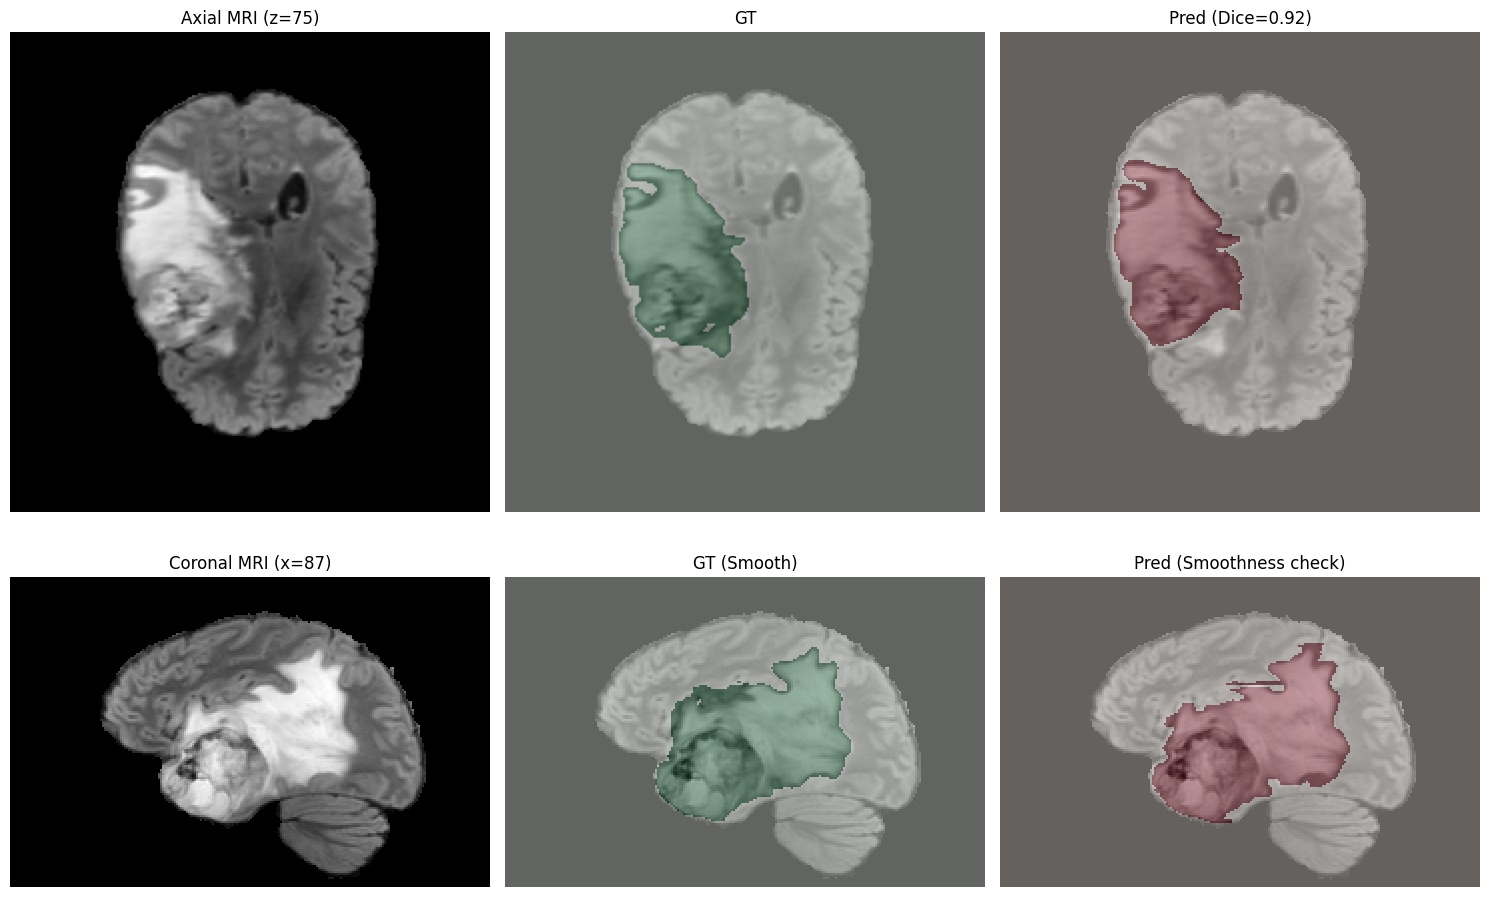

In [ ]:
import os, glob, math, random
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
import time
import gc

from transformers import Sam3Model
from peft import LoraConfig, get_peft_model
from monai.metrics import compute_hausdorff_distance, compute_dice, compute_average_surface_distance

# ==========================================
# 1) CONFIG
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_PATH = "/content/BraTS2021_Training_Data" # Change this if your data is elsewhere
MODEL_PATH = "/content/drive/MyDrive/sam3_scr_lora_jitter_BRaTS.pth" # Path to your finetuned model weights (if trained)
# Find trained model weights at https://www.kaggle.com/datasets/madhushreearavindan/sam3-trained-on-brats-scr-lora

SEG_RES = 512
NUM_PATIENTS = 50
GRACE_PERIOD = 2
THRESH = 0.35

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ==========================================
# 2) UTILS
# ==========================================
def norm_slice(x):
    x = x.astype(np.float32)
    nz = x > 0
    if nz.sum() < 10:
        return x
    lo, hi = np.percentile(x[nz], [1, 99])
    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo + 1e-8)
    return np.clip(x, 0, 1)

def largest_cc_2d(mask2d):
    lab, n = ndimage.label(mask2d.astype(np.uint8))
    if n == 0:
        return mask2d.astype(np.float32)
    sizes = ndimage.sum(mask2d, lab, index=np.arange(1, n+1))
    best = int(np.argmax(sizes) + 1)
    return (lab == best).astype(np.float32)

def largest_cc_3d(mask_3d):
    mask_bin = (mask_3d > 0).astype(np.uint8)
    labeled, num = ndimage.label(mask_bin)
    if num == 0:
        return mask_bin.astype(np.float32)
    sizes = ndimage.sum(mask_bin, labeled, index=np.arange(1, num + 1))
    largest = int(np.argmax(sizes) + 1)
    return (labeled == largest).astype(np.float32)

def box_from_mask_512(mask512, pad=6):
    ys, xs = np.where(mask512 > 0)
    if len(ys) == 0:
        return None
    x1 = max(0, int(xs.min()) - pad)
    y1 = max(0, int(ys.min()) - pad)
    x2 = min(SEG_RES - 1, int(xs.max()) + pad)
    y2 = min(SEG_RES - 1, int(ys.max()) + pad)
    if x2 <= x1 or y2 <= y1:
        return None
    return [x1, y1, x2, y2]

def center_box():
    return [160, 160, 352, 352]  # safe rough prompt

def generate_prompt_boxes():
    """
    9 rough clinician-like boxes in 512 space.
    """
    s = 192  # box size
    centers = [
        (256, 256),  # center
        (128, 128), (384, 128), (128, 384), (384, 384),  # corners
        (128, 256), (384, 256), (256, 128), (256, 384)   # mid edges
    ]

    boxes = []
    for cx, cy in centers:
        x1 = max(0, cx - s//2)
        y1 = max(0, cy - s//2)
        x2 = min(SEG_RES-1, cx + s//2)
        y2 = min(SEG_RES-1, cy + s//2)
        boxes.append([x1, y1, x2, y2])
    return boxes

# ==========================================
# 3) MODEL DEF (same as training)
# ==========================================
def force_resize_pos_embed(model, target_res=512):
    patch_size = 14
    grid_new = target_res // patch_size

    if hasattr(model, 'config'):
        if hasattr(model.config, 'vision_config'):
            model.config.vision_config.image_size = target_res
        elif hasattr(model.config, 'image_size'):
            model.config.image_size = target_res

    for name, tensor in list(model.named_parameters()) + list(model.named_buffers()):
        if 5184 in tensor.shape:
            D = tensor.shape[2] if tensor.ndim == 3 else tensor.shape[1]
            is_3d = (tensor.ndim == 3)
            grid_old = int(math.sqrt(5184))

            if is_3d:
                p = tensor.permute(0,2,1).view(1, D, grid_old, grid_old)
            else:
                p = tensor.unsqueeze(0).permute(0,2,1).view(1, D, grid_old, grid_old)

            r = F.interpolate(p, size=(grid_new, grid_new), mode="bicubic", align_corners=False)
            f = r.flatten(2).permute(0,2,1)
            if not is_3d:
                f = f.squeeze(0)

            path = name.split(".")
            m = model
            for step in path[:-1]:
                m = getattr(m, step)

            if isinstance(getattr(m, path[-1]), torch.nn.Parameter):
                setattr(m, path[-1], torch.nn.Parameter(f))
            else:
                setattr(m, path[-1], f)

class ConsistencyMedSAM(nn.Module):
    def __init__(self, base_model, lora_rank=16):
        super().__init__()
        peft_config = LoraConfig(
            r=lora_rank,
            target_modules=["q_proj", "k_proj", "v_proj"],
            bias="none"
        )
        base_model.vision_encoder = get_peft_model(base_model.vision_encoder, peft_config)
        self.model = base_model

    def forward(self, img, box):
        dummy_ids = torch.zeros((img.shape[0], 1), dtype=torch.long, device=img.device)
        outputs = self.model(
            pixel_values=img,
            input_boxes=box,
            input_ids=dummy_ids,
            multimask_output=False
        )
        masks = outputs.pred_masks
        return masks[:, 0:1]  # (B,1,h,w)

print("🔧 Loading SAM-3 + LoRA model...")
base = Sam3Model.from_pretrained("facebook/sam3")
force_resize_pos_embed(base.vision_encoder, target_res=SEG_RES)

model = ConsistencyMedSAM(base, lora_rank=16).to(DEVICE)

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print("✅ Loaded finetuned weights:", MODEL_PATH)
else:
    print("⚠️ MODEL NOT FOUND. Running random weights.")

model.eval()

# ==========================================
# 4) INFERENCE HELPERS
# ==========================================
@torch.no_grad()
def predict_slice(vol, z, box_512):
    sl = norm_slice(vol[:, :, z])
    img_t = torch.from_numpy(np.stack([sl]*3, axis=0)).float().unsqueeze(0).to(DEVICE)  # (1,3,H,W)
    img_t = F.interpolate(img_t, size=(SEG_RES, SEG_RES), mode="bilinear", align_corners=False)

    box_t = torch.tensor([[box_512]], device=DEVICE).float()  # (1,1,4)

    out = model(img_t, box_t)
    out = F.interpolate(out, size=(SEG_RES, SEG_RES), mode="bilinear", align_corners=False)
    prob = torch.sigmoid(out)[0, 0].float().cpu().numpy()
    return prob

def pick_start_slice_no_gt(vol):
    """
    NO GT.
    We scan 5 z candidates and 9 prompt boxes.
    Pick the (z, box) that yields the largest confident mask area.
    """
    Z = vol.shape[2]
    candidates = [int(Z*p) for p in [0.2, 0.35, 0.5, 0.65, 0.8]]
    candidates = [min(max(0, z), Z-1) for z in candidates]

    boxes = generate_prompt_boxes()

    best_score = -1
    best_z = Z // 2
    best_box = center_box()

    for z in candidates:
        for box in boxes:
            prob = predict_slice(vol, z, box)
            m = (prob > THRESH).astype(np.float32)
            m = largest_cc_2d(m)
            if m.sum() > 0.40 * (SEG_RES * SEG_RES):
              continue

            score = m.sum() * prob[m > 0].mean() if m.sum() > 0 else 0
            if score > best_score:
                best_score = score
                best_z = z
                best_box = box

    # if nothing detected anywhere, fallback
    if best_score < 50:
        return Z // 2, center_box()

    return best_z, best_box


def infer_volume(vol):
    H, W, Z = vol.shape
    pred = np.zeros((H, W, Z), dtype=np.float32)

    # ✅ now returns BOTH start_z and init_box
    start_z, init_box = pick_start_slice_no_gt(vol)

    # refine init box from first slice
    prob0 = predict_slice(vol, start_z, init_box)
    m0 = (prob0 > THRESH).astype(np.float32)
    m0 = largest_cc_2d(m0)

    refined = box_from_mask_512(m0, pad=6)
    if refined is not None:
        init_box = refined

    def run_dir(z_range, init_box):
        box = init_box
        grace = 0

        for z in z_range:
            prob = predict_slice(vol, z, box)
            m = (prob > THRESH).astype(np.float32)
            m = largest_cc_2d(m)

            if m.sum() < 30:
                grace += 1
                if grace > GRACE_PERIOD:
                    break
                continue
            grace = 0

            # ✅ RESIZE BACK TO ORIGINAL RESOLUTION
            m_t = torch.from_numpy(m).unsqueeze(0).unsqueeze(0).float()
            m_back = F.interpolate(m_t, size=(H, W), mode="nearest")[0,0].numpy()
            pred[:, :, z] = m_back

            # update box (still in 512 space)
            new_box = box_from_mask_512(m, pad=6)
            if new_box is not None:
                box = new_box

    run_dir(range(start_z, Z), init_box)
    run_dir(range(start_z - 1, -1, -1), init_box)

    pred = largest_cc_3d(pred)
    pred = ndimage.binary_fill_holes(pred > 0).astype(np.float32)
    return pred

# ==========================================
# 5) MAIN EVAL LOOP (WITH SPEED + VRAM)
# ==========================================

print(f"\n🖥 GPU: {torch.cuda.get_device_name(0)}")
print(f"\n🚀 Evaluating on up to {NUM_PATIENTS} volumes (NO GT prompting)...\n")

files = sorted(glob.glob(os.path.join(DATA_PATH, "**", "*_flair.nii.gz"), recursive=True))
random.shuffle(files)

dice_scores = []
hd95_scores = []
assd_scores = []

volume_times = []
volume_vrams = []

vis_data = None
count = 0

for f_path in files:
    if count >= NUM_PATIENTS:
        break

    pid = os.path.basename(f_path).replace("_flair.nii.gz", "")
    m_path = f_path.replace("_flair.nii.gz", "_seg.nii.gz")
    if not os.path.exists(m_path):
        continue

    vol = nib.load(f_path).get_fdata().astype(np.float32)
    gt = nib.load(m_path).get_fdata().astype(np.float32)
    gt = (gt > 0).astype(np.float32)

    if gt.sum() < 500:
        continue

    # -----------------------------
    # ⏱ SPEED + 🔥 VRAM MEASUREMENT
    # -----------------------------
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    start_time = time.time()

    pred = infer_volume(vol)

    torch.cuda.synchronize()
    end_time = time.time()

    volume_time = end_time - start_time
    peak_vram = torch.cuda.max_memory_allocated() / 1024**3

    volume_times.append(volume_time)
    volume_vrams.append(peak_vram)

    # -----------------------------
    # Metrics
    # -----------------------------
    pred_t = torch.from_numpy(pred).float().unsqueeze(0).unsqueeze(0)
    gt_t = torch.from_numpy(gt).float().unsqueeze(0).unsqueeze(0)

    pred_bin = (pred_t > 0).float()
    gt_bin = (gt_t > 0).float()

    d = float(compute_dice(pred_bin, gt_bin).item())

    try:
        hd = float(compute_hausdorff_distance(pred_bin, gt_bin, percentile=95).item())
    except:
        hd = 100.0

    try:
        assd = float(compute_average_surface_distance(pred_bin, gt_bin).mean().item())
    except:
        assd = 50.0

    dice_scores.append(d)
    hd95_scores.append(hd)
    assd_scores.append(assd)

    count += 1

    slices = vol.shape[2]
    time_per_slice = volume_time / slices

    print(
        f"[{count}/{NUM_PATIENTS}] {pid} | "
        f"Dice={d:.4f} | HD95={hd:.2f} | ASSD={assd:.2f} | "
        f"Time={volume_time:.2f}s ({time_per_slice:.4f}s/slice) | "
        f"Peak VRAM={peak_vram:.2f} GB"
    )

    if vis_data is None and 0.80 < d < 0.92:
        vis_data = (vol, gt, pred, d)

    del vol, gt, pred, pred_t, gt_t
    torch.cuda.empty_cache()

# ==========================================
# FINAL SUMMARY
# ==========================================

print("\n" + "="*60)
print(f"📊 FINAL RESULTS (N={len(dice_scores)})")
print(f"Mean Dice: {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
print(f"Mean HD95: {np.mean(hd95_scores):.2f} ± {np.std(hd95_scores):.2f}")
print(f"Mean ASSD: {np.mean(assd_scores):.2f} ± {np.std(assd_scores):.2f}")
print("-"*60)
print(f"⚡ Avg Volume Inference Time: {np.mean(volume_times):.2f} ± {np.std(volume_times):.2f} sec")
print(f"⚡ Avg Time per Slice: {np.mean(volume_times) / np.mean([vol.shape[2] for vol in [nib.load(f).get_fdata() for f in files[:len(volume_times)]]]):.4f} sec")
print(f"🔥 Avg Peak VRAM (Inference): {np.mean(volume_vrams):.2f} ± {np.std(volume_vrams):.2f} GB")
print("="*60)

# ==========================================
# 6) VISUALIZATION
# ==========================================
if vis_data:
    vol, gt, pred, d_score = vis_data

    idx = np.argwhere(gt > 0)
    if len(idx) > 0:
        cz = int(idx[:, 2].mean())   # axial z
        cx = int(idx[:, 0].mean())   # coronal x
    else:
        cz = vol.shape[2] // 2
        cx = vol.shape[0] // 2

    ax_img = np.rot90(vol[:, :, cz])
    ax_gt  = np.rot90(gt[:, :, cz])
    ax_pr  = np.rot90(pred[:, :, cz])

    cor_img = np.rot90(vol[cx, :, :])
    cor_gt  = np.rot90(gt[cx, :, :])
    cor_pr  = np.rot90(pred[cx, :, :])

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    axes[0,0].imshow(ax_img, cmap="gray"); axes[0,0].set_title(f"Axial MRI (z={cz})")
    axes[0,1].imshow(ax_img, cmap="gray"); axes[0,1].imshow(ax_gt, cmap="Greens", alpha=0.4); axes[0,1].set_title("GT")
    axes[0,2].imshow(ax_img, cmap="gray"); axes[0,2].imshow(ax_pr, cmap="Reds", alpha=0.4); axes[0,2].set_title(f"Pred (Dice={d_score:.2f})")

    axes[1,0].imshow(cor_img, cmap="gray"); axes[1,0].set_title(f"Coronal MRI (x={cx})")
    axes[1,1].imshow(cor_img, cmap="gray"); axes[1,1].imshow(cor_gt, cmap="Greens", alpha=0.4); axes[1,1].set_title("GT (Smooth)")
    axes[1,2].imshow(cor_img, cmap="gray"); axes[1,2].imshow(cor_pr, cmap="Reds", alpha=0.4); axes[1,2].set_title("Pred (Smoothness check)")

    for ax in axes.flatten():
        ax.axis("off")
    plt.tight_layout()
    plt.show()